# EDA — Smart Turn corpus

Day 1. The questions answered here determine everything downstream, which is why
this runs *before* a line of training code.

Four things to settle, in order of how much they change the plan:

1. **Class balance** — decides whether class weighting or a balanced sampler is needed at all.
2. **Speaker IDs** — decides whether a speaker-aware split is even possible.
3. **Indic / Hinglish content** — decides how much of section 3 has to be built by hand.
4. **Duration distribution** — decides the window length, the core latency/accuracy dial.

Run `python scripts/prepare_data.py --split train --max-rows 40000` first.

In [1]:
import warnings, sys, collections, json
warnings.filterwarnings("ignore")
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from src import SAMPLE_RATE
from src.dataset import WaveCache, describe_corpus_sizes

print(describe_corpus_sizes())

pipecat-ai/smart-turn-data-v3.2-train: 270,946 rows / 41.4 GB
pipecat-ai/smart-turn-data-v3.1-test:  31,473 rows /  4.3 GB
A full-corpus cache at 16 kHz int16 is roughly 35 GB, which is why the default configuration filters by language and caps rows.


## 1. What is actually in the cache

In [2]:
cache = WaveCache("../data/cache/train")
print(cache.summary())
print()
print("cache_info:", json.dumps(cache.info, indent=2)[:700])
print()
print("metadata columns:", sorted(cache.meta[0].keys()))

1,200 clips, 2.56 h, positive rate 0.517
  languages: eng=309, spa=80, hin=62, por=59, nld=55, fra=51 ...

cache_info: {
  "hf_dataset": "pipecat-ai/smart-turn-data-v3.2-train",
  "split": "train",
  "sample_rate": 16000,
  "dtype": "int16",
  "rows": 1200,
  "samples": 147335510,
  "hours": 2.557908159722222,
  "languages": "all",
  "include_synthetic": null,
  "max_seconds": 30.0,
  "min_seconds": 0.15,
  "skipped": 0,
  "skip_reasons": {}
}

metadata columns: ['audioduration', 'dataset', 'endfiller', 'endpoint_bool', 'id', 'language', 'midfiller', 'synthetic']


### Gate 1, question 1 — are there speaker IDs?

The answer decides whether the split is defensible or merely plausible.

In [3]:
cols = set(cache.meta[0].keys())
speaker_like = [c for c in cols
                if any(k in c.lower() for k in ("speaker", "spk", "voice", "person"))]
print("speaker-like columns:", speaker_like or "NONE")
print()
print("`id` is a per-clip UUID, not a speaker:")
for m in cache.meta[:3]:
    print("   ", m["id"])
print()
n_unique = len({m["id"] for m in cache.meta})
print(f"unique ids: {n_unique} of {len(cache.meta)} rows -> one id per clip")
print()
print("CONCLUSION: no speaker identifier exists. A speaker-aware split is")
print("impossible and must not be claimed. The coarsest honest grouping is")
print("`dataset`, the source corpus:")
print("   ", dict(collections.Counter(m["dataset"] for m in cache.meta).most_common()))

speaker-like columns: NONE

`id` is a per-clip UUID, not a speaker:
    00006fe3-5331-4db2-b30e-65affe00cfbe
    000081dd-b6dc-420c-be34-57bd8224c18f
    0000abee-a101-4a2f-bdb5-aecae1187830

unique ids: 1200 of 1200 rows -> one id per clip

CONCLUSION: no speaker identifier exists. A speaker-aware split is
impossible and must not be claimed. The coarsest honest grouping is
`dataset`, the source corpus:
    {'chirp3_1': 634, 'chirp3_2': 303, 'liva_1': 137, 'midcentury_1': 45, 'rime_2': 21, 'mundo_1': 15, 'human_5': 13, 'orpheus_grammar_1': 12, 'orpheus_endfiller_1': 11, 'orpheus_midfiller_1': 5, 'human_convcollector_1': 4}


## 2. Class balance

In [4]:
y = cache.labels()
pos, neg = int(y.sum()), int((y == 0).sum())
print(f"endpoint=True  : {pos:>7,d}  ({pos / y.size:.3f})")
print(f"endpoint=False : {neg:>7,d}  ({neg / y.size:.3f})")
print()
ratio = max(pos, neg) / max(min(pos, neg), 1)
print(f"imbalance ratio: {ratio:.2f}x")
print("->", "class weighting is worth applying" if ratio > 1.2
      else "barely imbalanced; still lead with F1 and the confusion matrix")

endpoint=True  :     620  (0.517)
endpoint=False :     580  (0.483)

imbalance ratio: 1.07x
-> barely imbalanced; still lead with F1 and the confusion matrix


### Gate 1, question 2 — is there Indic / Hinglish audio?

The plan assumed there would be none. Checking rather than assuming changes Day 8.

In [5]:
INDIC = ("hin", "ben", "mar", "tam", "tel", "guj", "kan", "mal", "pan", "urd")
langs = collections.Counter(m["language"] for m in cache.meta)
print(f"{len(langs)} languages present")
print()
for lang, n in langs.most_common():
    mark = "   <-- Indic" if lang in INDIC else ""
    print(f"  {lang:<6s} {n:>7,d}{mark}")

indic = {l: n for l, n in langs.items() if l in INDIC}
print()
if indic:
    print(f"FINDING: Indic audio IS present -> {indic}")
    print("So there is a real held-out Indic evaluation slice, reported separately.")
    print("Still missing: code-switched Hinglish, Indian-English accent, and")
    print("logistics-domain vocabulary. That is what data/hinglish/ supplies.")
else:
    print("No Indic audio — the whole of section 3 has to be built by hand.")

23 languages present

  eng        309
  spa         80
  hin         62   <-- Indic
  por         59
  nld         55
  fra         51
  rus         47
  zho         43
  tur         43
  ara         42
  fin         39
  pol         39
  deu         38
  vie         37
  ben         34   <-- Indic
  mar         33   <-- Indic
  nor         32
  ind         29
  dan         29
  ukr         28
  kor         27
  jpn         26
  ita         18

FINDING: Indic audio IS present -> {'ben': 34, 'hin': 62, 'mar': 33}
So there is a real held-out Indic evaluation slice, reported separately.
Still missing: code-switched Hinglish, Indian-English accent, and
logistics-domain vocabulary. That is what data/hinglish/ supplies.


## 3. Duration — this is what sets the window length

In [6]:
dur = np.asarray([float(m["audioduration"]) for m in cache.meta])
print("duration percentiles (s):")
for q in (0, 5, 25, 50, 75, 95, 100):
    print(f"  p{q:<3d} {np.percentile(dur, q):6.2f}")
print()
for w in (0.5, 1.0, 1.5, 2.0, 4.0, 8.0):
    covered = float((dur <= w).mean())
    print(f"  a {w:>4.1f}s window fully contains {covered:6.1%} of clips "
          f"(the rest are left-trimmed, keeping the tail)")

duration percentiles (s):
  p0     0.83
  p5     3.05
  p25    5.08
  p50    7.16
  p75    9.87
  p95   13.80
  p100  22.16

  a  0.5s window fully contains   0.0% of clips (the rest are left-trimmed, keeping the tail)
  a  1.0s window fully contains   0.1% of clips (the rest are left-trimmed, keeping the tail)
  a  1.5s window fully contains   0.1% of clips (the rest are left-trimmed, keeping the tail)
  a  2.0s window fully contains   0.7% of clips (the rest are left-trimmed, keeping the tail)
  a  4.0s window fully contains  13.2% of clips (the rest are left-trimmed, keeping the tail)
  a  8.0s window fully contains  59.2% of clips (the rest are left-trimmed, keeping the tail)


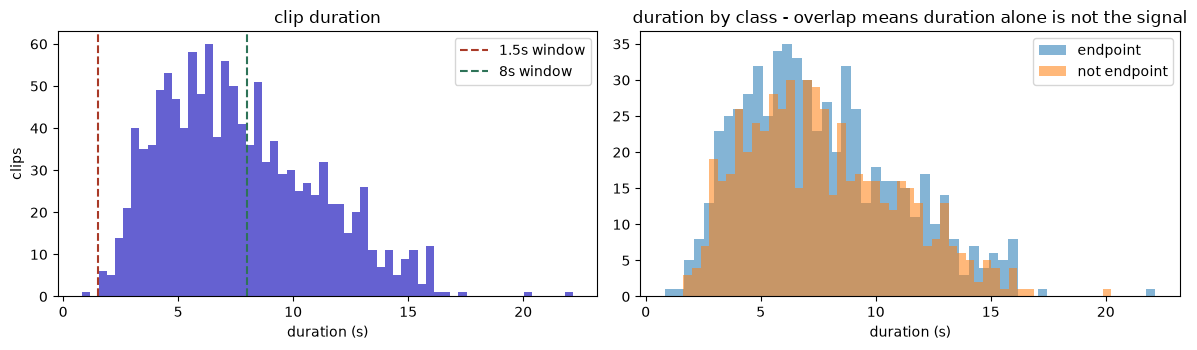

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].hist(dur, bins=60, color="#4A45C9", alpha=0.85)
for w, c in [(1.5, "#A93A28"), (8.0, "#2E7358")]:
    ax[0].axvline(w, color=c, ls="--", lw=1.5, label=f"{w:g}s window")
ax[0].set_xlabel("duration (s)")
ax[0].set_ylabel("clips")
ax[0].legend()
ax[0].set_title("clip duration")

for lbl, m in [("endpoint", y == 1), ("not endpoint", y == 0)]:
    ax[1].hist(dur[m], bins=50, alpha=0.55, label=lbl)
ax[1].set_xlabel("duration (s)")
ax[1].legend()
ax[1].set_title("duration by class - overlap means duration alone is not the signal")
plt.tight_layout()
plt.show()

## 4. The filler annotations — free error-mode labels

`midfiller` and `endfiller` are the most useful discovery in this notebook. The
error modes the plan expected to hand-categorise on Day 9 are already labelled.

Note they are **tri-state**: `True`, `False`, or `null` for un-annotated rows.
Folding `null` into `False` would mix "annotated as no filler" with "unknown".

In [8]:
for col in ("midfiller", "endfiller", "synthetic"):
    vals = collections.Counter(str(m.get(col)) for m in cache.meta)
    print(f"{col:<12s} {dict(vals)}")
print()
mf = np.asarray([m.get("midfiller") is True for m in cache.meta])
ef = np.asarray([m.get("endfiller") is True for m in cache.meta])
un = np.asarray([m.get("midfiller") is None for m in cache.meta])
rows = [("endfiller=True", ef), ("midfiller=True", mf),
        ("neither (annotated)", ~mf & ~ef & ~un), ("unannotated", un)]
for name, m in rows:
    if m.sum():
        print(f"  {name:<22s} n={int(m.sum()):>7,d}  positive rate {y[m].mean():.3f}")
print()
print("Read that table carefully. If endfiller=True has a positive rate near 0,")
print("a trailing filler NEVER marks a turn end -- which is exactly the")
print("false-interruption trap, already labelled for us.")

midfiller    {'True': 468, 'None': 263, 'False': 469}
endfiller    {'False': 635, 'None': 263, 'True': 302}
synthetic    {'True': 986, 'False': 214}

  endfiller=True         n=    302  positive rate 0.000
  midfiller=True         n=    468  positive rate 0.515
  neither (annotated)    n=    276  positive rate 0.884
  unannotated            n=    263  positive rate 0.513

Read that table carefully. If endfiller=True has a positive rate near 0,
a trailing filler NEVER marks a turn end -- which is exactly the
false-interruption trap, already labelled for us.


## 5. Listen to clips by hand — there is no substitute for this

In [9]:
from IPython.display import Audio, display

rng = np.random.default_rng(0)
sample = rng.choice(len(cache), size=min(20, len(cache)), replace=False)
for i in sample[:8]:
    m = cache.meta[int(i)]
    w = cache.wave(int(i))
    print(f"[{i}] label={int(bool(m['endpoint_bool']))} lang={m['language']} "
          f"src={m['dataset']} dur={w.size / SAMPLE_RATE:.2f}s "
          f"midfill={m.get('midfiller')} endfill={m.get('endfiller')}")
    display(Audio(w, rate=SAMPLE_RATE))

[1088] label=1 lang=rus src=chirp3_1 dur=8.08s midfill=False endfill=False


[364] label=1 lang=nld src=chirp3_1 dur=11.84s midfill=False endfill=False


[319] label=1 lang=eng src=rime_2 dur=6.49s midfill=None endfill=None


[1122] label=0 lang=dan src=chirp3_2 dur=10.04s midfill=False endfill=True


[604] label=1 lang=mar src=chirp3_2 dur=5.20s midfill=True endfill=False


[724] label=0 lang=por src=chirp3_1 dur=9.56s midfill=True endfill=True


[671] label=0 lang=tur src=chirp3_1 dur=8.40s midfill=False endfill=True


[1160] label=1 lang=kor src=chirp3_1 dur=4.72s midfill=True endfill=False


### What to write down while listening

From your own ears, not from the metadata:

- What does a **positive** actually sound like? Falling pitch? A completed clause? A breath?
- What does a **negative** sound like? Is the incompleteness audible, or only grammatical?
- Are any labels **wrong**? If boundaries are fuzzy that is a ceiling no
  architecture fixes — and it belongs in the report as a finding, not hidden.

## 6. Loudness and trailing silence — how much can a silence timer even get?

RMS dBFS: p5 -23.2  median -18.5  p95 -15.9
-> a wide spread is why normalisation matters: gain correlates with source
   corpus, so an un-normalised model can score well by learning the corpus.



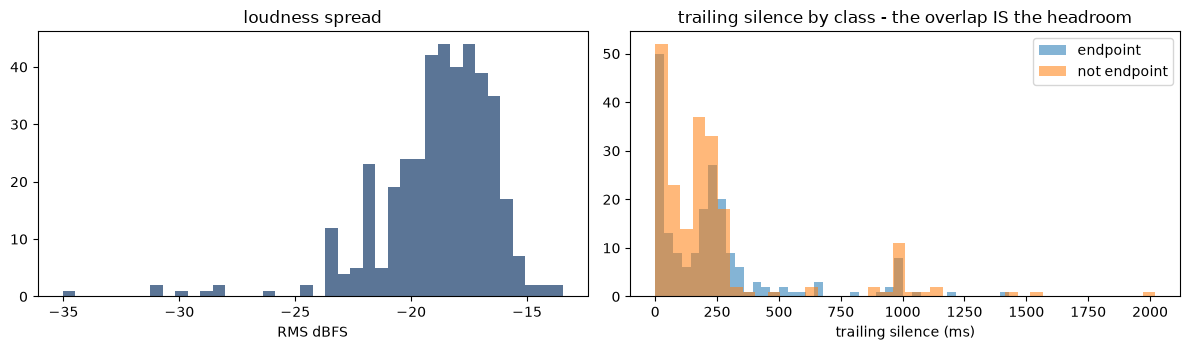

In [10]:
from src.audio import rms_dbfs
from src.baselines import EnergyBaseline

eb = EnergyBaseline()
n = min(400, len(cache))
sub = np.random.default_rng(1).choice(len(cache), size=n, replace=False)
levels = np.asarray([rms_dbfs(cache.wave(int(i))) for i in sub])
trail = np.asarray([eb.score(cache.wave(int(i))) for i in sub])
lab = np.asarray([cache.label(int(i)) for i in sub])

print(f"RMS dBFS: p5 {np.percentile(levels, 5):.1f}  "
      f"median {np.median(levels):.1f}  p95 {np.percentile(levels, 95):.1f}")
print("-> a wide spread is why normalisation matters: gain correlates with source")
print("   corpus, so an un-normalised model can score well by learning the corpus.")
print()
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].hist(levels, bins=40, color="#5B7596")
ax[0].set_xlabel("RMS dBFS")
ax[0].set_title("loudness spread")
for l, nm in [(1, "endpoint"), (0, "not endpoint")]:
    ax[1].hist(trail[lab == l], bins=40, alpha=0.55, label=nm)
ax[1].set_xlabel("trailing silence (ms)")
ax[1].legend()
ax[1].set_title("trailing silence by class - the overlap IS the headroom")
plt.tight_layout()
plt.show()

## Conclusions to carry into Day 2

Gate 1 is "answer these before Day 2". Write the answers here.

| question | answer |
|---|---|
| speaker IDs? | **No** — group by `dataset`, state the limitation in the report |
| class balance | see section 2 — weight only if the ratio warrants it |
| Indic audio? | see section 3 — a real `hin`/`ben`/`mar` slice exists |
| window length | see section 3 — the reference uses 8 s; sweep it in E2 |
| label noise | from section 5 listening — if fuzzy, that is a reported ceiling |